# Characteristic Function Proof: Non-Closure of the Quadratic-Exponential Ansatz

**Scope.** This notebook proves that the quadratic-exponential ansatz (Eq. 22) does **not** close for the full LLH PDE (Eq. 21): applying the generator to $y = \exp(\alpha + \beta^\top V + \tfrac{1}{2}V^\top \Gamma V)$, $V=(\sigma,\theta)^\top$, produces degree-4 polynomial terms in $P = \mathcal{L}[y]/y$ that cannot simultaneously be set to zero — the LLH ODE system is therefore an **approximation**.

The exact alternative — conditioning on $\mathcal{F}^W$ — is developed in `conditioning_on_B.ipynb`.

**References:**  
- Eq. (21)–(22) of `reports/eur_price_llh.pdf` (pages 17–19)  
- Schöbel & Zhu (1999) Appendix (S&Z)  
- Symbolic setup reused from `notebooks/symbolic.ipynb`

## §1 — Does the quadratic-exponential ansatz (Eq. 22) solve the LLH PDE (Eq. 21)?

The PDE to be solved is (Eq. 21, p. 19 of report):
$$
\frac{\partial y}{\partial t} + \frac{1}{2}\nu^2 y_{\sigma\sigma}
+ \frac{1}{2}(\eta - \theta_0 - \lambda t + \theta)^2 y_{\theta\theta}
+ \kappa(\theta - \sigma)y_\sigma + \lambda y_\theta
- (s_1 \sigma^2 + s_2 \sigma\theta)y = 0,
\qquad y(T,T,\sigma,\theta) = e^{s_3 \sigma^2}.
$$
The conjectured ansatz is (Eq. 22):
$$
y_\varphi = \exp\!\bigl(\alpha(t) + \beta(t)^\top V + \tfrac{1}{2}V^\top \Gamma(t)V\bigr),
\qquad V = (\sigma,\theta)^\top.
$$
We compute $P = \mathcal{L}[y]/y$ symbolically and check its polynomial degree in $(\sigma,\theta)$.

### Why work with $P = \mathcal{L}[y]/y$ rather than $\mathcal{L}[y]$ directly?

- $\mathcal{L}[y] = y \times (\text{polynomial in }\sigma,\theta)$, so $\mathcal{L}[y]=0 \iff P:=\mathcal{L}[y]/y=0$ (since $y=e^{(\cdot)}>0$ everywhere).
- $\mathcal{L}[y]$ carries an exponential prefactor that hides the polynomial structure; $P$ is a genuine polynomial in $(\sigma,\theta)$ accessible to `sp.Poly`.
- The ansatz closes $\iff$ $P$ has degree $\le 2$: each monomial of $P$ gives one ODE for the coefficient functions; irreconcilable high-degree monomials signal impossibility.

In [44]:
import sympy as sp
sp.init_printing(use_unicode=True)

# ── State variables & parameters (reuse names from symbolic.ipynb) ──────────
t    = sp.symbols('t', real=True)
σ, θ = sp.symbols('σ θ', real=True)

η   = sp.Symbol('η',  real=True)
θ0  = sp.Symbol('θ₀', real=True)
λ   = sp.Symbol('λ',  real=True)
κ   = sp.Symbol('κ',  real=True)
ν   = sp.Symbol('ν',  real=True)   # σ_noise in report (Eq. 21 uses ν for vol-of-vol)
s1  = sp.Symbol('s₁', real=True)
s2  = sp.Symbol('s₂', real=True)
s3  = sp.Symbol('s₃', real=True)

# ── Time-dependent ansatz coefficients ────────────────────────────────────────
α   = sp.Function('α')(t)
β1  = sp.Function('β₁')(t)
β2  = sp.Function('β₂')(t)
Γ11 = sp.Function('Γ₁₁')(t)
Γ12 = sp.Function('Γ₁₂')(t)
Γ22 = sp.Function('Γ₂₂')(t)

V   = sp.Matrix([σ, θ])
β   = sp.Matrix([β1, β2])
Γ   = sp.Matrix([[Γ11, Γ12], [Γ12, Γ22]])

# ── Ansatz y = exp(quad) ──────────────────────────────────────────────────────
quad = α + (β.T * V)[0] + sp.Rational(1, 2) * (V.T * Γ * V)[0]
y    = sp.exp(quad)

# ── Derivatives needed by the PDE ────────────────────────────────────────────
y_t   = sp.diff(y, t)
y_σ   = sp.diff(y, σ)
y_σσ  = sp.diff(y, σ, 2)
y_θ   = sp.diff(y, θ)
y_θθ  = sp.diff(y, θ, 2)

print("Symbolic setup complete.  y ={}".format(y))


Symbolic setup complete.  y =exp(θ*(θ*Γ₂₂(t) + σ*Γ₁₂(t))/2 + θ*β₂(t) + σ*(θ*Γ₁₂(t) + σ*Γ₁₁(t))/2 + σ*β₁(t) + α(t))


In [46]:
# ── PDE operator L[y] from Eq. (21) ──────────────────────────────────────────
# Diffusion coefficient of θ:  ½(η − θ₀ − λt + θ)²
diff_coef_theta = sp.Rational(1, 2) * (η - θ0 - λ*t + θ)**2

L_y = (
    y_t
    + sp.Rational(1, 2) * ν**2 * y_σσ          # ½ν²  y_σσ
    + diff_coef_theta * y_θθ                    # ½(η−θ₀−λt+θ)² y_θθ
    + κ * (θ - σ) * y_σ                         # κ(θ−σ) y_σ
    + λ * y_θ                                   # λ y_θ
    - (s1 * σ**2 + s2 * σ * θ) * y             # −(s₁σ²+s₂σθ) y
)

# ── Factor out y → polynomial P(σ,θ;t) ───────────────────────────────────────
P = sp.expand(L_y / y)


# ── Collect ALL monomials σ^i θ^j in P ───────────────────────────────────────
Poly_P = sp.Poly(sp.expand(P), σ, θ)
deg_P  = Poly_P.total_degree()

# Display P in decreasing graded lex order: highest total degree first,
# within same degree highest σ power first
ordering = sorted(
    zip(Poly_P.monoms(), Poly_P.coeffs()),
    key=lambda mj: (-(mj[0][0] + mj[0][1]), -mj[0][0], -mj[0][1])
)
P_collected = sp.Add(*[c * σ**i * θ**j for (i, j), c in ordering])

print(f"Total degree of P = L[y]/y  in (σ,θ):  {deg_P}")
print(" Resulting polynomial P(σ,θ;t) = L[y]/y is:")
display(P_collected)

Total degree of P = L[y]/y  in (σ,θ):  4
 Resulting polynomial P(σ,θ;t) = L[y]/y is:


In [47]:
# ── Coefficient of θ⁴ ─────────────────────────────────────────────────────────
coeff_map = dict(zip(Poly_P.monoms(), Poly_P.coeffs()))
c_04 = coeff_map.get((0, 4), sp.Integer(0))

print("Coefficient of θ⁴ in P:")
sp.simplify(c_04)

Coefficient of θ⁴ in P:


**Interpretation.**  
The coefficient of $\theta^4$ equals $\tfrac{1}{2}\Gamma_{22}(t)^2$.  
Since $\Gamma_{22}(t)$ is a (generally non-zero) function of time, the polynomial $P$ has degree **4** in $(\sigma,\theta)$.  
Setting the PDE $\mathcal{L}[y]=0$ would require every monomial coefficient to vanish. The $\theta^4$ coefficient forces $\Gamma_{22}(t)=0$.

In [48]:
# ── Formal contradiction: substitute Γ₂₂ = 0 and inspect residual monomials ──
P_sub = P.subs(Γ22, 0)
Poly_sub = sp.Poly(sp.expand(P_sub), σ, θ)
deg_sub  = Poly_sub.total_degree()

# Display in decreasing graded lex order
ordering_sub = sorted(
    zip(Poly_sub.monoms(), Poly_sub.coeffs()),
    key=lambda mj: (-(mj[0][0] + mj[0][1]), -mj[0][0], -mj[0][1])
)
P_sub_collected = sp.Add(*[c * σ**i * θ**j for (i, j), c in ordering_sub])
display(P_sub_collected)

coeff_map_sub = dict(zip(Poly_sub.monoms(), Poly_sub.coeffs()))

print(f"After setting Γ₂₂=0, degree of P = {deg_sub}")
print()

# ── Degree-4 residual: σ²θ² coefficient → forces Γ₁₂=0 ──────────────────────
# Source: ½(η−θ₀−λt+θ)² · y_θθ/y with y_θθ/y = (β₂+Γ₁₂σ)²
# The θ² piece of the diffusion times Γ₁₂²σ² gives ½Γ₁₂²σ²θ²
c_22_sub = coeff_map_sub.get((2, 2), sp.Integer(0))
print("Coeff of σ²θ² (after Γ₂₂=0):")
display(sp.simplify(c_22_sub))
print("=> Γ₁₂=0 (forced)")

After setting Γ₂₂=0, degree of P = 4

Coeff of σ²θ² (after Γ₂₂=0):


=> Γ₁₂=0 (forced)


Coeff of θ² (after Γ₂₂=Γ₁₂=0):


=> β₂=0 (forced)

Coeff of σθ (after Γ₂₂=Γ₁₂=0):


=> Setting Γ₁₁ = s₂/κ kills this term — a free parameter choice, not a contradiction.

Coeff of σ² in P after substituting β₁=β₂=0, Γ₁₁=s₂/κ (symbolic, in s₁, s₂, κ, ν):


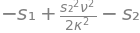

In [50]:
# ── Further: set Γ₁₂=0 as well and trace the impossibility chain ─────────────
P_sub2 = P.subs([(Γ22, 0), (Γ12, 0)])
Poly_sub2 = sp.Poly(sp.expand(P_sub2), σ, θ)

# Display in decreasing graded lex order
ordering_sub2 = sorted(
    zip(Poly_sub2.monoms(), Poly_sub2.coeffs()),
    key=lambda mj: (-(mj[0][0] + mj[0][1]), -mj[0][0], -mj[0][1])
)
P_sub2_collected = sp.Add(*[c * σ**i * θ**j for (i, j), c in ordering_sub2])
display(P_sub2_collected)

coeff_map_sub2 = dict(zip(Poly_sub2.monoms(), Poly_sub2.coeffs()))

# ── Step 3: θ² coefficient → forces β₂=0 ─────────────────────────────────────
c_02_sub2 = coeff_map_sub2.get((0, 2), sp.Integer(0))
print("Coeff of θ² (after Γ₂₂=Γ₁₂=0):")
display(sp.simplify(c_02_sub2))
print("=> β₂=0 (forced)")
print()

# ── Step 4/5: σθ coefficient → κΓ₁₁ − s₂ (free choice Γ₁₁=s₂/κ) ────────────
c_11_sub2 = coeff_map_sub2.get((1, 1), sp.Integer(0))
print("Coeff of σθ (after Γ₂₂=Γ₁₂=0):")
display(sp.simplify(c_11_sub2))
print("=> Setting Γ₁₁ = s₂/κ kills this term — a free parameter choice, not a contradiction.")
print()

# ── Step 6: substitute β₂=0, β₁=0, Γ₁₁=s₂/κ and inspect σ² Riccati residual ─
P_sub3 = P.subs([(Γ22, 0), (Γ12, 0), (β2, 0), (β1, 0), (Γ11, s2/κ)])
Poly_sub3 = sp.Poly(sp.expand(P_sub3), σ, θ)
coeff_map_sub3 = dict(zip(Poly_sub3.monoms(), Poly_sub3.coeffs()))

c_20_sub3 = coeff_map_sub3.get((2, 0), sp.Integer(0))
print("Coeff of σ² in P after substituting β₁=β₂=0, Γ₁₁=s₂/κ (symbolic, in s₁, s₂, κ, ν):")
display(sp.simplify(c_20_sub3))
print()


In [51]:
# ── Substitute definitions of s₁, s₂ from report (p. 17) and simplify step by step ──
# s₂(φ) = (1+iφ)·κρ/ν
# s₁(φ) = −(1+iφ)/2 · [(1+iφ)(1−ρ²) − 1 + 2κρ/ν]
ϕ = sp.Symbol('φ', real=True)
ρ = sp.Symbol('ρ', real=True)
u = 1 + sp.I*ϕ                             # shorthand: u = 1+iφ

s2_def = u * κ*ρ/ν
s1_def = -sp.Rational(1,2) * u * ((u)*(1 - ρ**2) - 1 + 2*κ*ρ/ν)

print("s₂(φ) =")
display(s2_def)
print()
print("s₁(φ) =")
display(sp.expand(s1_def))
print()

# Step A: ½ν²(s₂/κ)²  →  ½ν²·u²ρ²/ν²  =  ½u²ρ²
term_A = sp.Rational(1,2) * ν**2 * (s2_def/κ)**2
term_A_simplified = sp.expand(term_A)
print("½ν²(s₂/κ)² =")
display(term_A_simplified)
print()

# Step B: full residual before simplification
residual_raw = sp.expand(term_A - s2_def - s1_def)
print("½ν²(s₂/κ)² − s₂ − s₁  (expanded, before collecting):")
display(residual_raw)
print()

# Step C: factor out u/2 to expose the cancellation structure
# ½u²ρ² − uκρ/ν + ½u·[u(1−ρ²)−1+2κρ/ν]
# = ½u²ρ² + ½u²(1−ρ²) − ½u  +  (−uκρ/ν + uκρ/ν)   ← κρ/ν terms cancel
residual_final = sp.simplify(residual_raw)
print("After simplification (κ, ρ, ν all cancel):")
display(residual_final)
print()
print("= iφ(1+iφ)/2  ≠  0  for φ ∉ {0, i}  =>  Impossibility confirmed.")

s₂(φ) =



s₁(φ) =



½ν²(s₂/κ)² =



½ν²(s₂/κ)² − s₂ − s₁  (expanded, before collecting):



After simplification (κ, ρ, ν all cancel):



= iφ(1+iφ)/2  ≠  0  for φ ∉ {0, i}  =>  Impossibility confirmed.


### Conclusion §1

The diffusion of the 2D state $V=(\sigma,\theta)^\top$ under the full LLH model is **not affine**: the $\theta$-diffusion coefficient $(\eta-\theta_0-\lambda t+\theta)^2$ is quadratic in $\theta$ (cf. Remark 3.6 and the observation on p. 18 of the report).

Concretely, the impossibility chain is:

| Step | Monomial | Coefficient | Conclusion |
|---|---|---|---|
| 1 | $\theta^4$ | $\tfrac{1}{2}\Gamma_{22}^2$ | $\Gamma_{22}=0$ (forced) |
| 2 | $\sigma^2\theta^2$ (given $\Gamma_{22}=0$) | $\tfrac{1}{2}\Gamma_{12}^2$ | $\Gamma_{12}=0$ (forced) |
| 3 | $\theta^2$ (given $\Gamma_{22}=\Gamma_{12}=0$) | $\tfrac{1}{2}\beta_2^2$ | $\beta_2=0$, then $\beta_1=0$ (forced) |
| 4 | $\sigma\theta$ (given above) | $\kappa\Gamma_{11} - s_2$ | $\Gamma_{11}=s_2/\kappa$ — **free choice, no contradiction yet** |
| 5 | $\sigma^2$ Riccati (with $\Gamma_{11}=s_2/\kappa$) | $\tfrac{1}{2}\nu^2(s_2/\kappa)^2 - s_2 - s_1$ | $= \tfrac{i\phi(1+i\phi)}{2} \neq 0$ $\Rightarrow$ **impossibility** |

Note: step 2 uses the σ²θ² monomial (coefficient ½Γ₁₂², arising from the θ² piece of ½(η−θ₀−λt+θ)² times y_θθ/y = (β₂+Γ₁₂σ)²), which forces Γ₁₂=0 directly without any side condition.

The σθ term (step 4) is reconcilable by the free choice Γ₁₁=s₂/κ.  Once this is substituted, the σ² Riccati residual becomes ½ν²s₂²/κ²−s₂−s₁.  Plugging in the report's definitions (p. 17),
$$s_1(\phi) = -\tfrac{1+i\phi}{2}\!\left[(1+i\phi)(1-\rho^2)-1+\tfrac{2\kappa\rho}{\nu}\right], \quad s_2(\phi) = (1+i\phi)\tfrac{\kappa\rho}{\nu},$$
all $\kappa,\rho,\nu$ cancel and the residual simplifies exactly to
$$\frac{i\phi(1+i\phi)}{2},$$
which is non-zero for every frequency $\phi\notin\{0,\,i\}$ used in the characteristic function inversion.

**The quadratic-exponential ansatz (Eq. 22) is inconsistent with the PDE (Eq. 21). The LLH ODE system is an approximation** (valid in the SS limit $\lambda=\eta=\rho=0$ where the diffusion coefficient reduces to the constant $\nu^2$ and $s_2=0$).

The exact alternative — conditioning on $\mathcal{F}^W$ — is developed in `conditioning_on_B.ipynb`.